### MD005 - Sistemes Basats en el Coneixement

#### Segona entrega: Classificació

##### Professora: Jordina Torrents
##### Data d'entrega: 22 de gener de 2026
#### Nom de l'alumne: Gerard Pascual Fontanilles

#### Informació sobre el conjunt de dades

Per fer aquest treball he utilitzat el conjunt de dades de pokemons, ja que em sembla un tema interessant i divertit per treballar. S'ha extret de: https://www.kaggle.com/datasets/hamzacyberpatcher/data-of-1010-pokemons

El conjunt de dades conté informació sobre 1025 pokemons diferents, incloent-hi les seves estadístiques bàsiques, tipus, generació i si evolucionen d'algun altre pokemon.

Les característiques principals del conjunt de dades són:
* Pokemon's id
* Pokemon's name
* Pokemon's rank (whether it is legendary, mythical, baby or an ordinary pokemon)
* Pokemon's generation
* The pokemon from which this pokemon evolved from
* It's primary and secondary type as type1 and type2
* It's base stats
* It's height (decimetres) and weight (hectograms)
* It's abilities (Note: if a pokemon has multiple abilities such as overgrow and chlorophyll than they are separated by a space and if there is a space in the name of the ability it has been replaced by a hyphen for example a pokemon with abilities blaze and solar power it is given as blaze solar-power)
* A little description of the pokemon in english (description of pokemons from 1009 is marked as "Not Available").

### Imports necessaris

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('pokemons.csv')

In [3]:
df.head()

,id,name,rank,generation,evolves_from,type1,type2,hp,atk,def,spatk,spdef,speed,total,height,weight,abilities,desc
0,1,bulbasaur,ordinary,generation-i,nothing,grass,poison,45,49,49,65,65,45,318,7,69,overgrow chlorophyll,A strange seed was planted on its back at birt...
1,2,ivysaur,ordinary,generation-i,bulbasaur,grass,poison,60,62,63,80,80,60,405,10,130,overgrow chlorophyll,"When the bulb on its back grows large, it appe..."
2,3,venusaur,ordinary,generation-i,ivysaur,grass,poison,80,82,83,100,100,80,525,20,1000,overgrow chlorophyll,The plant blooms when it is absorbing solar en...
3,4,charmander,ordinary,generation-i,nothing,fire,NaN,39,52,43,60,50,65,309,6,85,blaze solar-power,"Obviously prefers hot places. When it rains, s..."
4,5,charmeleon,ordinary,generation-i,charmander,fire,NaN,58,64,58,80,65,80,405,11,190,blaze solar-power,"When it swings its burning tail, it elevates t..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            1025 non-null   int64 
 1   name          1025 non-null   object
 2   rank          1025 non-null   object
 3   generation    1025 non-null   object
 4   evolves_from  1025 non-null   object
 5   type1         1025 non-null   object
 6   type2         526 non-null    object
 7   hp            1025 non-null   int64 
 8   atk           1025 non-null   int64 
 9   def           1025 non-null   int64 
 10  spatk         1025 non-null   int64 
 11  spdef         1025 non-null   int64 
 12  speed         1025 non-null   int64 
 13  total         1025 non-null   int64 
 14  height        1025 non-null   int64 
 15  weight        1025 non-null   int64 
 16  abilities     1025 non-null   object
 17  desc          1025 non-null   object
dtypes: int64(10), object(8)
memory usage: 144.3+ KB


Primer de tot eliminem les columnes que no aporten informació rellevant per al model, com ara `desc`, `id`, `name` i `total`.

Descartem `desc`, `id`, `name` perquè no aporten informació útil per a la classificació i`total` és redundant ja que és la suma de les altres estadístiques i podria introduir multicolinealitat.

In [5]:
df.drop(columns=['desc', 'id', 'name', 'total'], inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   rank          1025 non-null   object
 1   generation    1025 non-null   object
 2   evolves_from  1025 non-null   object
 3   type1         1025 non-null   object
 4   type2         526 non-null    object
 5   hp            1025 non-null   int64 
 6   atk           1025 non-null   int64 
 7   def           1025 non-null   int64 
 8   spatk         1025 non-null   int64 
 9   spdef         1025 non-null   int64 
 10  speed         1025 non-null   int64 
 11  height        1025 non-null   int64 
 12  weight        1025 non-null   int64 
 13  abilities     1025 non-null   object
dtypes: int64(8), object(6)
memory usage: 112.2+ KB


Veiem com ara conjunt de dades realment té 1025 entrades (Pokémons), com ens deien a la descripció del conjunt de dades i 13 columnes (característiques), després d'haver eliminat les que no aportaven informació rellevant.

Totes semblen estar completes excepte la columna `type2`, que té valors nuls (NaN), suposem que és per als pokémons que només tenen un tipus.

Procedim a comprovar-ho:

In [9]:
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

type2    499
dtype: int64


Com es pot veure, només la columna `type2` té valors nuls (NaN). Això té sentit, ja que alguns pokémons només tenen un tipus (type1) i no tenen un segon tipus (type2).

De moment omplim els nuls de type2 amb 'None' per indicar que no tenen segon tipus. Després analitzarem més a fons la columna per veure si fa falta eliminar-la o transformar-la.

In [10]:
df['type2'] = df['type2'].fillna('None')

Mirant la resta de variables, la columna `evolves_from`, veiem que no hi ha cap valor nul (NaN), cosa que és estranya. Ja que alguns pokémons no evolucionen d'altres, haurien de tenir valors nuls (NaN) en aquesta columna. Ho comprovem:

In [11]:
print(df['evolves_from'].unique()[:10])

['nothing' 'bulbasaur' 'ivysaur' 'charmander' 'charmeleon' 'squirtle'
 'wartortle' 'caterpie' 'metapod' 'weedle']


Com podem veure, la columna `evolves_from` no té valors nuls (NaN), sinó que utilitza la paraula "nothing" per indicar que un pokémon no evoluciona d'altre. Això explica per què df.info() ens deia que no hi havia nuls en aquesta columna.

In [12]:
print(df['evolves_from'].value_counts().head())

evolves_from
nothing    541
eevee        8
tyrogue      3
applin       3
scyther      2
Name: count, dtype: int64


Com podem veure, hi ha molts pokémons que no evolucionen d'altre (valor "nothing"). Creem una nova columna que simplifiqui aquesta informació, al model normalment li importa més si el pokémon és una forma base o no, que saber exactament de qui ve.

Ja que si utilitzem aquesta columna tal qual, el model tractarà 'nothing' com una categoria més. Això està bé, però té un problema: la columna tindrà centenars de categories diferents (una per a cada pokémon que evoluciona), cosa que pot confondre alguns models.

Definim una nova columna binària `is_base` que indiqui si un pokémon és una forma base (1- no evoluciona de ningú) o no (0- evoluciona d'un altre pokémon).

In [14]:
df['is_base'] = df['evolves_from'].apply(lambda x: 1 if x == 'nothing' else 0)
display(df[['evolves_from', 'is_base']].head())

,evolves_from,is_base
0,nothing,1
1,bulbasaur,0
2,ivysaur,0
3,nothing,1
4,charmander,0


Hem comprovat que la nova columna `is_base` funciona correctament. 1 indica que el pokémon és una forma base (no evoluciona de ningú) i 0 indica que sí que evoluciona d'un altre pokémon. Ara eliminem la columna original 'evolves_from', ja que no la farem servir.

In [15]:
df.drop(columns=['evolves_from'], inplace=True)

In [16]:
df.head()

,rank,generation,type1,type2,hp,atk,def,spatk,spdef,speed,height,weight,abilities,is_base
0,ordinary,generation-i,grass,poison,45,49,49,65,65,45,7,69,overgrow chlorophyll,1
1,ordinary,generation-i,grass,poison,60,62,63,80,80,60,10,130,overgrow chlorophyll,0
2,ordinary,generation-i,grass,poison,80,82,83,100,100,80,20,1000,overgrow chlorophyll,0
3,ordinary,generation-i,fire,None,39,52,43,60,50,65,6,85,blaze solar-power,1
4,ordinary,generation-i,fire,None,58,64,58,80,65,80,11,190,blaze solar-power,0


Abans de continuar, fem una comprovació final de valors nuls (NaN) en tot el DataFrame:

In [22]:
print(df.isnull().sum().sum())

0


Perfecte, no hi ha més valors nuls ni categories que simbolitzin nuls. Ara comprovem si hi ha files duplicades:

In [21]:
duplicated_count = df.duplicated().sum()
print(f"Número de files duplicades: {duplicated_count}")

Número de files duplicades: 0


Tenim 0 files duplicades. Ara ja podem fer una revisió ràpida de les dades per detectar possibles errors o inconsistències.

Comprovem primer les columnes numèriques calculant estadístiques descriptives bàsiques:

In [23]:
df.describe()

,hp,atk,def,spatk,spdef,speed,height,weight,is_base
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,70.184390,77.521951,72.507317,70.080976,70.205854,67.186341,12.116098,669.865366,0.527805
std,26.631054,29.782541,29.286972,29.658378,26.639329,28.717227,12.481673,1212.731138,0.499470
min,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.000000,1.000000,0.000000
25%,50.000000,55.000000,50.000000,47.000000,50.000000,45.000000,5.000000,85.000000,0.000000
50%,68.000000,75.000000,70.000000,65.000000,67.000000,65.000000,10.000000,280.000000,1.000000
75%,85.000000,100.000000,90.000000,90.000000,86.000000,88.000000,15.000000,700.000000,1.000000
max,255.000000,181.000000,230.000000,173.000000,230.000000,200.000000,200.000000,9999.000000,1.000000


L'anàlisi descriptiu (`describe`) confirma la necessitat de preprocessament abans d'entrenar els models:

1. **Integritat de les dades:** Totes les columnes tenen un `count` de 1025 i els valors mínims són lògics (cap valor 0 o negatiu en estadístiques vitals), confirmant una vegada més que no hi ha valors nuls amagats.
2. **Disparitat d'Escales:** Existeix una diferència massiva de magnituds entre variables. Mentre que l'`atk` o la `def` es mouen en rangs de 5 a 250, el `weight` (pes) arriba fins a gairebé 10.000 (hg).
3. **Presència d'Outliers:** Tant en pes com en alçada, el valor màxim està molt allunyat del 75è percentil, indicant la presència de valors extrems (Pokémons gegants o molt pesats).

Aquesta disparitat de rangs justifica l'aplicació obligatòria d'un **escalat de dades (`StandardScaler`)**. Sense ell, variables com el pes dominarien injustament el càlcul de distàncies en algoritmes eclipsant variables crítiques però de menor magnitud com la velocitat.

Tot i així, abans de seguir endavant, fem una anàlisi visual de les variables numèriques per detectar possibles outliers (valors extrems) que podrien distorsionar els models.

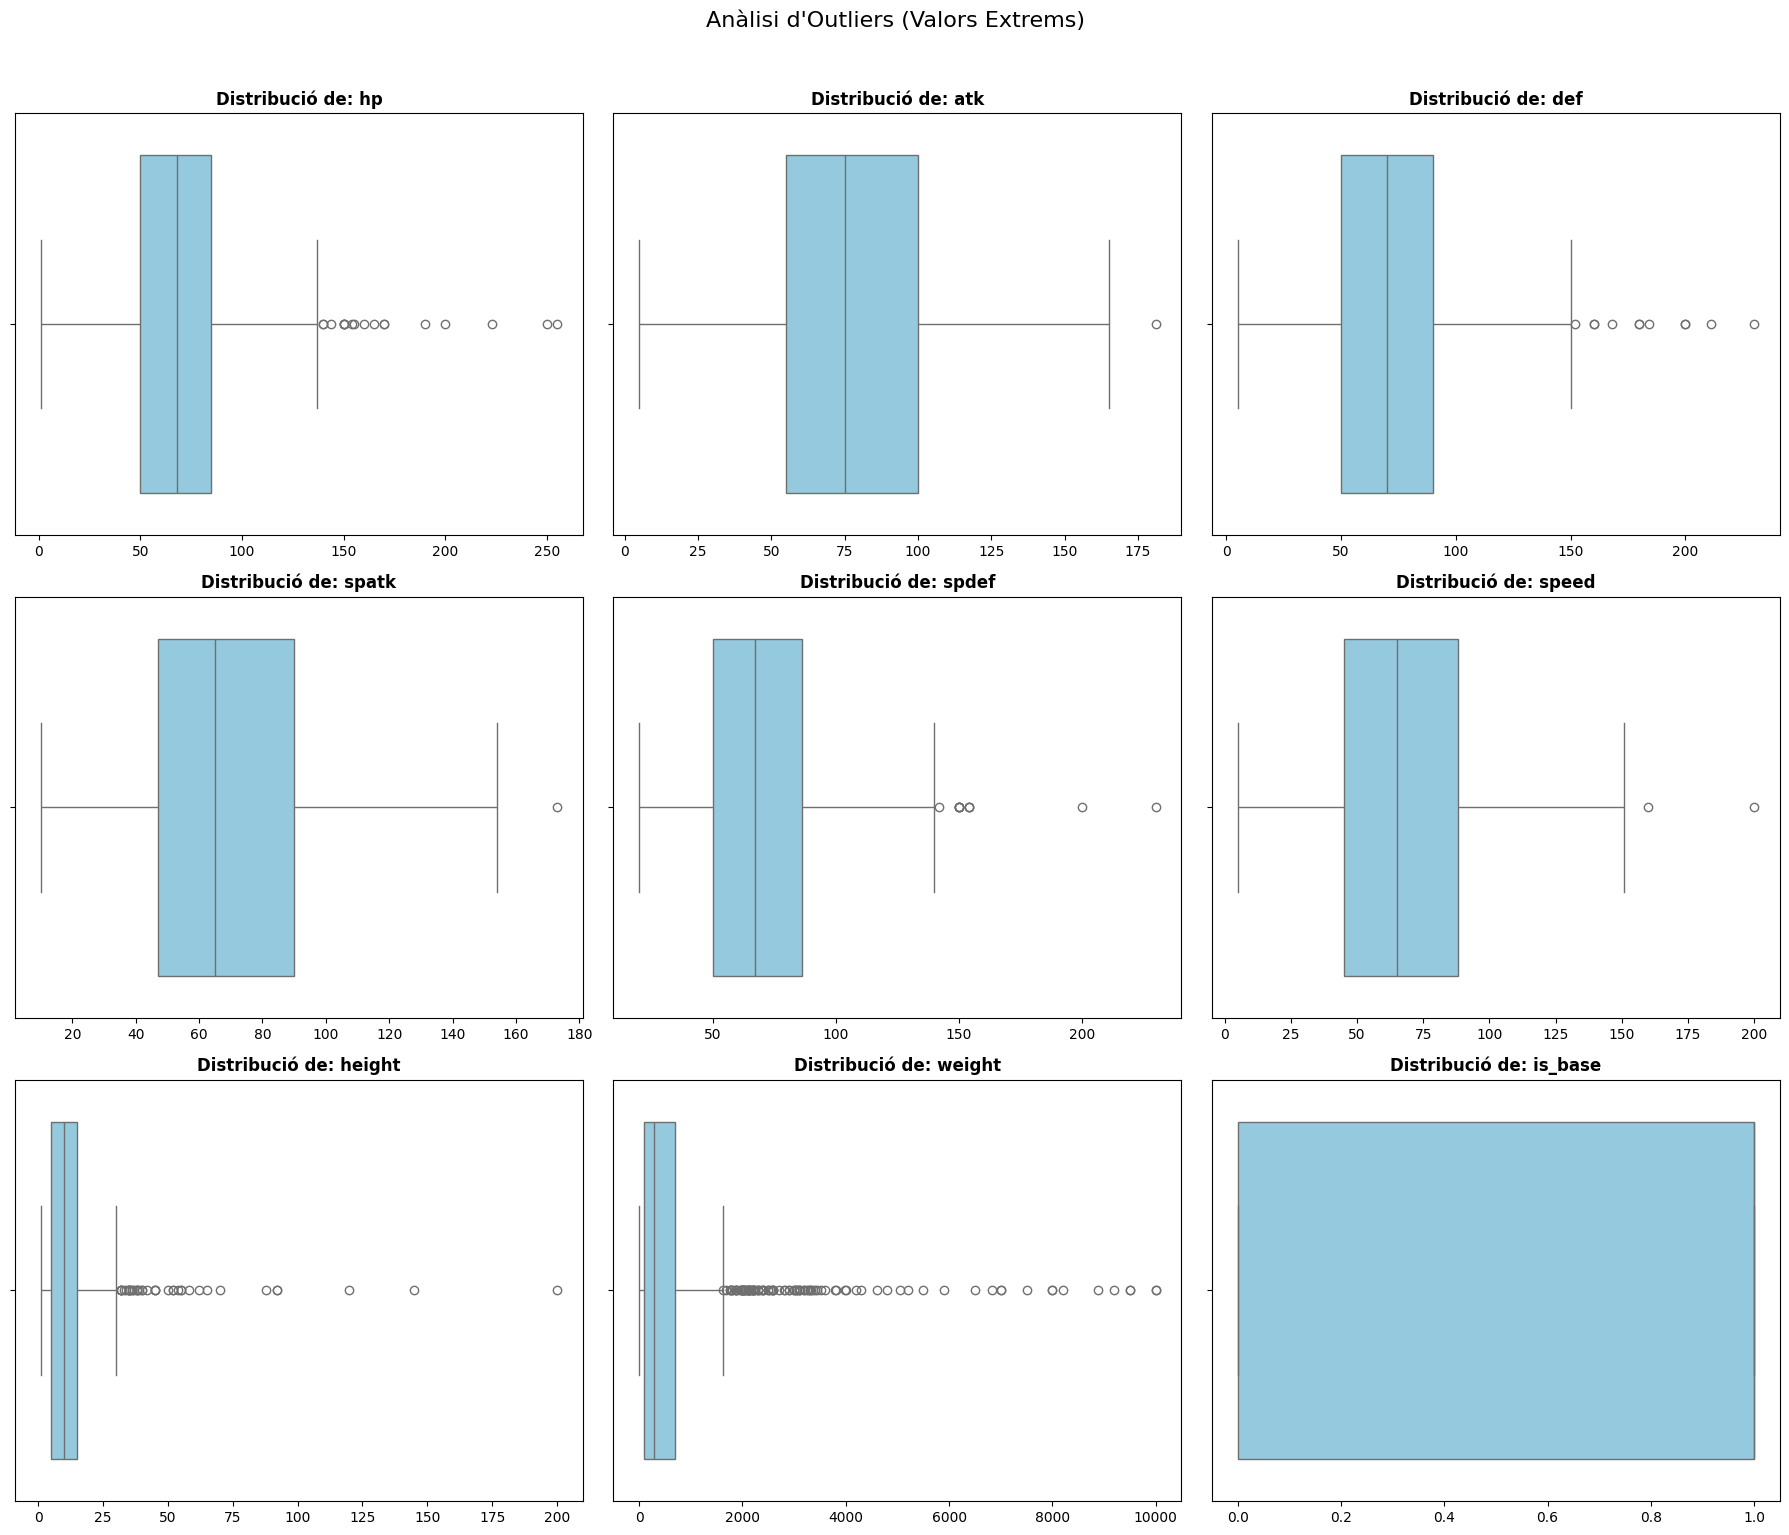

In [33]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
plot_cols = [c for c in numeric_cols]

num_plots = len(plot_cols)
cols = 3
rows = math.ceil(num_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.boxplot(data=df, x=col, ax=axes[i], color='skyblue')

    axes[i].set_title(f'Distribució de: {col}', fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Anàlisi d\'Outliers (Valors Extrems)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [34]:
print("TOP 5 POKÉMON MÉS PESATS")
display(df[['weight', 'rank', 'generation']].nlargest(5, 'weight'))
print("\nTOP 5 POKÉMON AMB MÉS VIDA (HP)")
display(df[['hp', 'rank', 'generation']].nlargest(5, 'hp'))
print("\nTOP 5 POKÉMON MÉS RÀPIDS")
display(df[['speed', 'rank', 'generation']].nlargest(5, 'speed'))

TOP 5 POKÉMON MÉS PESATS


,weight,rank,generation
789,9999,legendary,generation-vii
796,9999,ordinary,generation-vii
382,9500,legendary,generation-iii
889,9500,legendary,generation-viii
749,9200,ordinary,generation-vii



TOP 5 POKÉMON AMB MÉS VIDA (HP)


,hp,rank,generation
241,255,ordinary,generation-ii
112,250,ordinary,generation-i
798,223,ordinary,generation-vii
894,200,legendary,generation-viii
201,190,ordinary,generation-ii



TOP 5 POKÉMON MÉS RÀPIDS


,speed,rank,generation
893,200,legendary,generation-viii
290,160,ordinary,generation-iii
794,151,ordinary,generation-vii
100,150,ordinary,generation-i
385,150,mythical,generation-iii


Tots els pokémons són reals, no hi ha errors evidents en les dades. Els outliers detectats (com *Celesteela* o *Snorlax*) són pokémons legítims coneguts per les seves estadístiques extremes. Això és coherent amb la naturalesa del dataset, on els pokémons llegendaris i alguns normals poden tenir estadístiques molt altes. Es pot saber quins pokémons són amb el id, que és el seu número de la pokédex.

Per tant, no eliminarem cap outlier, ja que formen part integral del domini i poden aportar senyal valuós per a la classificació.

També generem un mapa de calor de correlacions per veure com es relacionen les estadístiques numèriques entre si i amb la variable `rank` (si és llegendari o no).

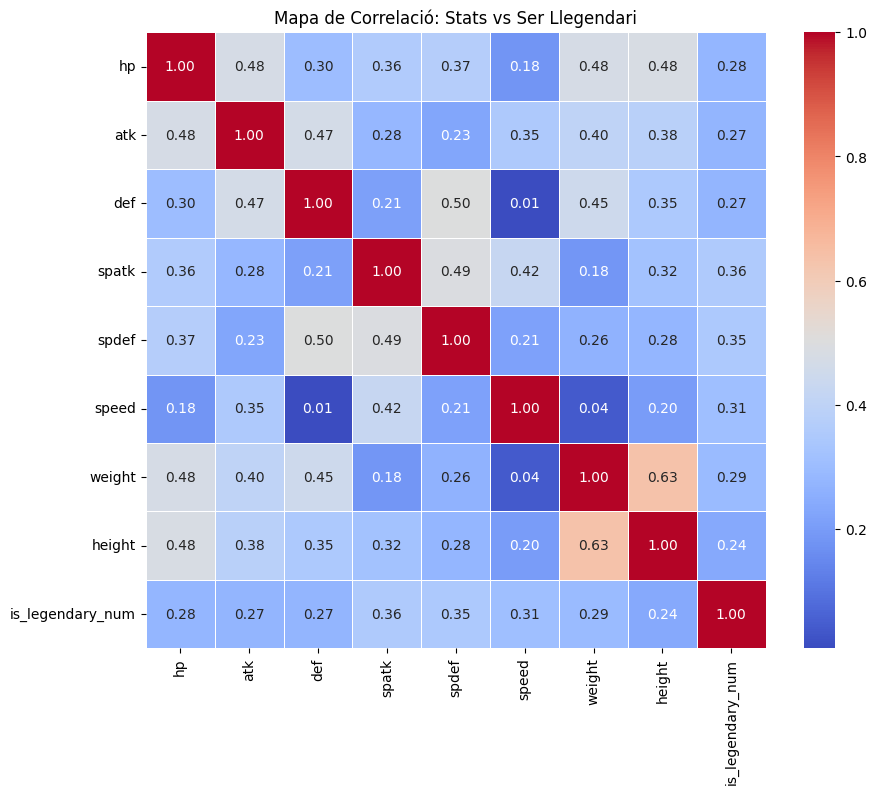

In [35]:
df_corr = df.copy()

df_corr['is_legendary_num'] = df_corr['rank'].apply(lambda x: 1 if x in ['legendary', 'mythical'] else 0)

numeric_cols_corr = ['hp', 'atk', 'def', 'spatk', 'spdef', 'speed', 'weight', 'height', 'is_legendary_num']
correlation_matrix = df_corr[numeric_cols_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Mapa de Correlació: Stats vs Llegendari")
plt.show()

L'anàlisi de la matriu de correlació mostra relacions lògiques però moderades:

* **Correlació màxima:** Trobem un **0.63** entre `height` i `weight`, lògic ja que la mida influeix en el pes.
* **Altres relacions:** `spdef` i `def` (0.50) o `hp` amb les variables físiques (0.48).

**Decisió Tècnica: Conservar totes les variables.**
Cap parell de variables supera el llindar crític de redundància (habitualment > 0.85 o 0.90). Això indica que no existeix multicolinealitat severa. Per exemple, tot i la relació Pes-Alçada, existeixen prous excepcions (Pokémon petits però densos/pesats) perquè ambdues variables aportin informació única al model.

Per tant, procedim utilitzant totes les característiques numèriques.

Una vegada comprovades les variables numèriques, passem a les categòriques.

Ara fem una anàlisi visual de les variables categòriques per veure la seva distribució i detectar possibles problemes com classes molt desbalancejades o categories amb massa valors únics.

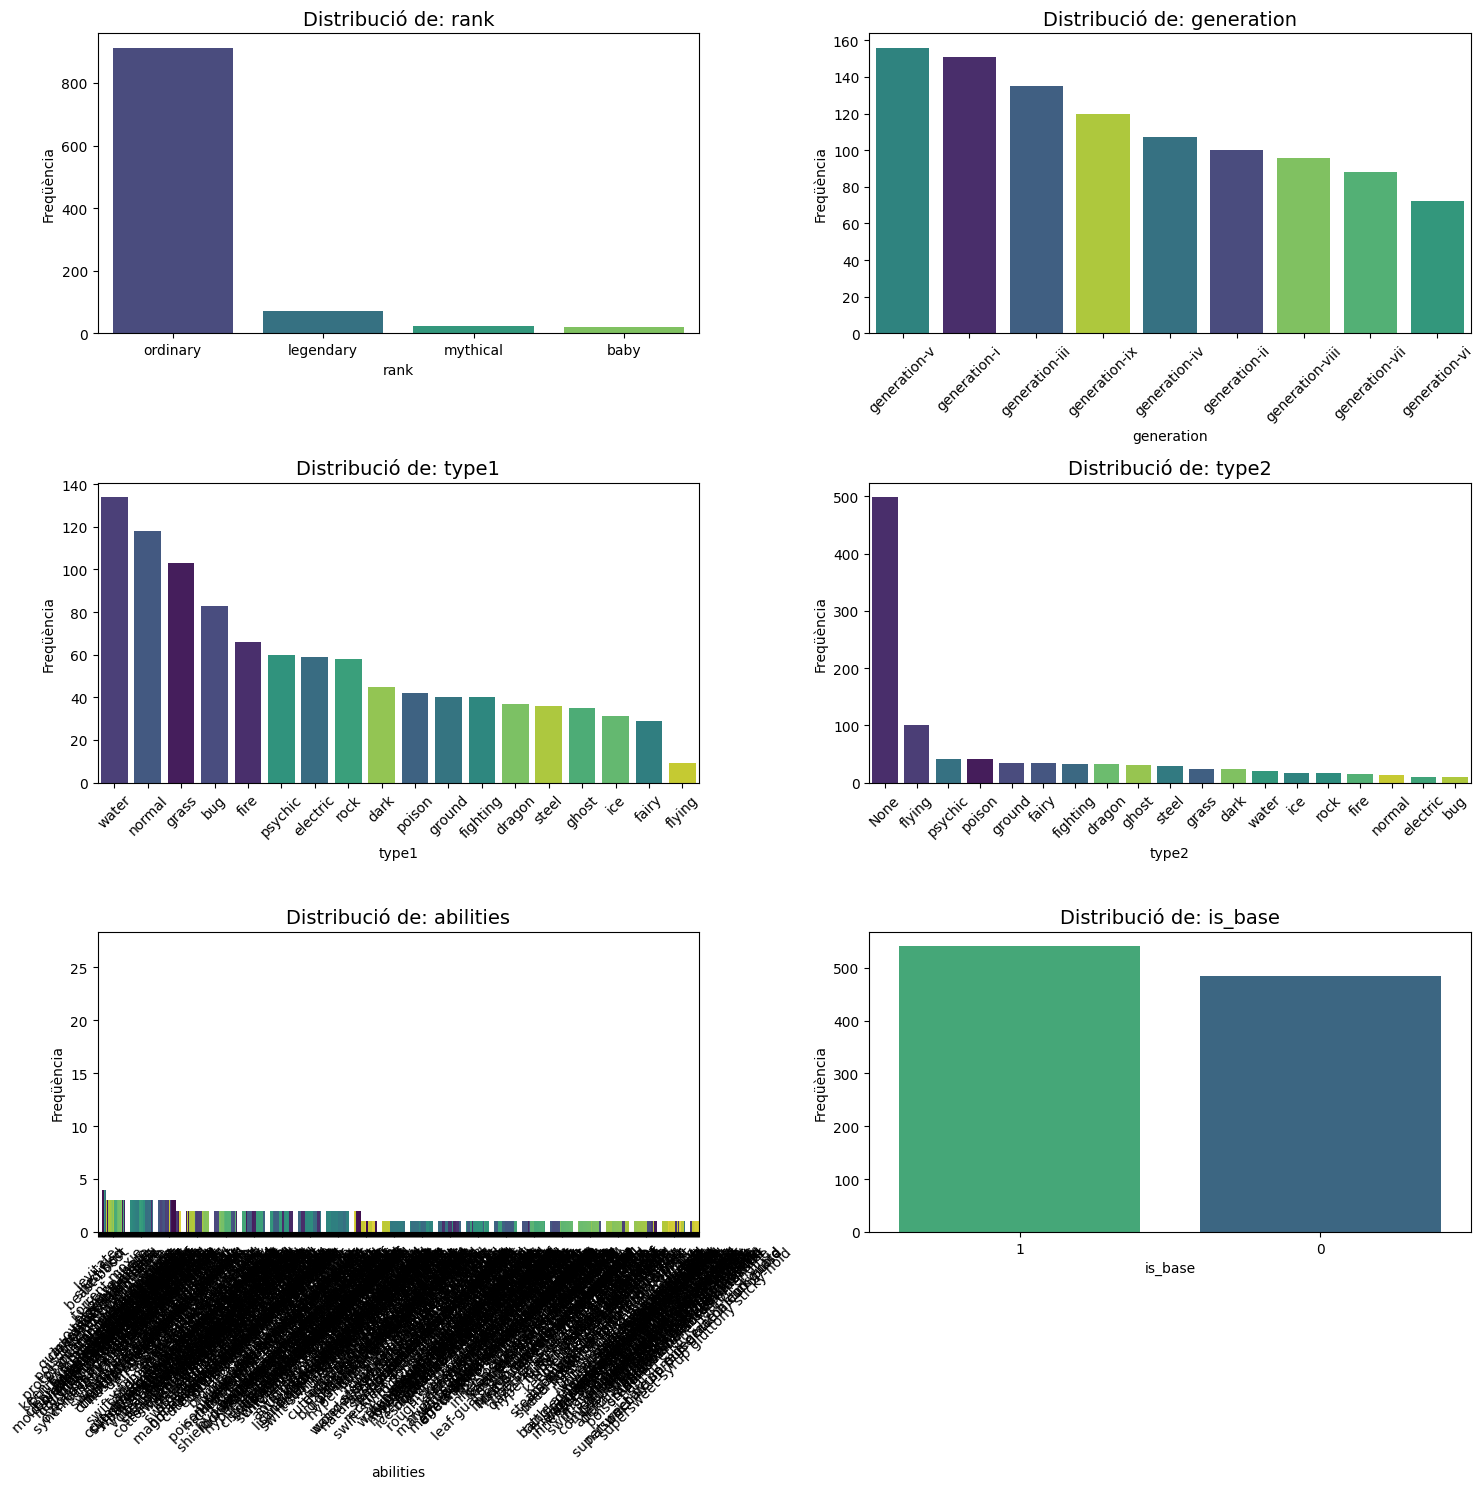

In [27]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'is_base' in df.columns:
    cat_cols.append('is_base')

num_plots = len(cat_cols)
cols = 2
rows = math.ceil(num_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order_values = df[col].value_counts().index

    sns.countplot(
        data=df,
        x=col,
        hue=col,
        legend=False,
        order=order_values,
        ax=axes[i],
        palette='viridis'
    )

    axes[i].set_title(f'Distribució de: {col}', fontsize=14)
    axes[i].set_ylabel('Freqüència')

    if len(order_values) > 5:
        axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Els gràfics de barres revelen patrons clars de desequilibri en diverses variables:

* **`rank`:** Confirmem visualment un desbalanceig extrem. La classe `ordinary` domina absolutament sobre `legendary`, `mythical` i `baby`. Malgrat aquest desequilibri, aquesta variable és perfectament vàlida com a Target (veurem més endavant), ja que reflecteix la realitat del domini (els Pokémon llegendaris són, per definició, escassos).
* **Tipus Secundari (`type2`):** S'observa també un fort desequilibri, amb algunes categories molt freqüents (com *Flying*) i altres gairebé inexistents. La gran quantitat de valors nuls (ara marcats com 'None') que vèiem inicialment també és un factor a tenir en compte.

Donada l'alta cardinalitat i desequilibri detectats, procedirem a inspeccionar més a fons les variables **`abilities`** i **`type2`** per determinar si aporten prou senyal predictiu o si introdueixen massa soroll i convé eliminar-les.

In [29]:
print("'TYPE2'")
null_type2_count = df[df['type2'] == 'None'].shape[0]
total_pokemon = df.shape[0]
percent_null = (null_type2_count / total_pokemon) * 100
print(f"Total Pokémon sense Type2 ('None'): {null_type2_count} de {total_pokemon}")
print(f"Percentatge de buits: {percent_null:.2f}%")
print("\nDistribució dels Tipus Secundaris (Top 10):")
print(df['type2'].value_counts().head(10))

print("\n\n'ABILITIES'")
unique_abilities = df['abilities'].nunique()
top_ability = df['abilities'].mode()[0]
freq_top = df['abilities'].value_counts().iloc[0]
print(f"Número de combinacions d'habilitats úniques: {unique_abilities}")
print(f"Cardinalitat (Unicitat): {(unique_abilities/total_pokemon)*100:.2f}% de les files són diferents.")
print(f"\nHabilitat més repetida: '{top_ability}' (només apareix {freq_top} vegades)")
print("\nMostra de les 10 habilitats més freqüents:")
print(df['abilities'].value_counts().head(10))

'TYPE2'
Total Pokémon sense Type2 ('None'): 499 de 1025
Percentatge de buits: 48.68%

Distribució dels Tipus Secundaris (Top 10):
type2
None        499
flying      100
psychic      42
poison       41
ground       35
fairy        35
fighting     33
dragon       33
ghost        30
steel        29
Name: count, dtype: int64


'ABILITIES'
Número de combinacions d'habilitats úniques: 623
Cardinalitat (Unicitat): 60.78% de les files són diferents.

Habilitat més repetida: 'levitate ' (només apareix 27 vegades)

Mostra de les 10 habilitats més freqüents:
abilities
levitate                              27
beast-boost                           11
protosynthesis protosynthesis          8
quark-drive quark-drive                8
shed-skin                              5
poison-point rivalry hustle            4
keen-eye tangled-feet big-pecks        4
justified                              4
clear-body light-metal                 4
mold-breaker own-tempo pickpocket      3
Name: count, dtype: int64


Basant-nos en els resultats, procedim a eliminar `abilities` i `type2` per simplificar el model:

* **`abilities`:** Té una cardinalitat excessiva (623 valors únics). Codificar-la generaria centenars de columnes irrellevants sense aportar patrons clars.
* **`type2`:** Gairebé la meitat de les dades (49%) són nul·les, la qual cosa redueix dràsticament la seva utilitat predictiva.

Assumim que la classificació dependrà principalment de les **Estadístiques Numèriques (`stats`)**. Els Pokémon es defineixen pel seu "poder " (valors en Atac Especial, Velocitat, etc.), per la qual cosa esperem que aquests números siguin discriminadors molt més potents que les descripcions textuals.

In [30]:
df.drop(columns=['abilities', 'type2'], inplace=True)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   rank        1025 non-null   object
 1   generation  1025 non-null   object
 2   type1       1025 non-null   object
 3   hp          1025 non-null   int64 
 4   atk         1025 non-null   int64 
 5   def         1025 non-null   int64 
 6   spatk       1025 non-null   int64 
 7   spdef       1025 non-null   int64 
 8   speed       1025 non-null   int64 
 9   height      1025 non-null   int64 
 10  weight      1025 non-null   int64 
 11  is_base     1025 non-null   int64 
dtypes: int64(9), object(3)
memory usage: 96.2+ KB


Ens quedem finalment amb 11 columnes: 8 numèriques (estadístiques i mesures físiques) i 3 categòriques (rank, generation, is_base).

### Classes:
Al tractar-se d'un problema de classificació, identifiquem variables que permetin realitzar tant classificació binària com multiclasse. Existeixen variables en el dataset que compleixin amb aquesta característica?

Sí, hem identificat variables categòriques en el dataset que permetrien plantejar problemes de classificació (tant binària com multiclasse), encara que la seva viabilitat depèn de la correlació amb les variables predictives (stats).

**1. `rank` (La variable seleccionada - Única Viable):**
És la candidata ideal i l'única que permetrà un model robust, ja que existeix una correlació directa (causalitat) entre ser "Llegendari" i tenir estadístiques de combat superiors.
* **Multiclasse:** Originalment conté 4 classes: `ordinary`, `legendary`, `mythical` i `baby`. Podríem entrenar un model per distingir entre les quatre.
* **Binària:** Permet una transformació lògica molt neta agrupant **`legendary` + `mythical**` (Classe 1) vs. **`ordinary` + `baby**` (Classe 0). Aquest serà el nostre enfocament inicial.

**2. `type1` (Tècnicament possible, pràcticament inviable):**
Aquesta variable representa l'element principal (Foc, Aigua, Planta...).
* **El Problema:** Tot i que tècnicament podríem intentar classificar-la (18 classes o "Foc vs No Foc"), les estadístiques de combat no determinen el tipus. Un Pokémon ràpid i fort pot ser tant Elèctric com Drac o Lluita. Hi ha massa solapament en les distribucions numèriques perquè un model aprengui patrons clars.

**3. `generation` (No viable):**
Representa la generació de llançament del joc (Gen 1 a Gen 9).
* Aquesta variable és purament cronològica (metadada). Les estadístiques de combat d'un Pokémon no depenen de l'any en què va ser creat; un Pokémon de la Generació 1 pot tenir exactament els mateixos stats que un de la Generació 9. Un model intentant predir això es comportaria de manera gairebé aleatòria.

### Ara es detallen les tècniques de Ciència de Dades necessàries per implementar ambdós enfocaments (Binari i Multiclasse) utilitzant la variable `rank` i `type1`:

Per implementar els models de classificació basats en les variables identificades, caldria aplicar les següents tècniques específiques:

#### Variable `rank` (Target Principal)

**1. Enfocament Binari (Llegendari vs. No Llegendari)**
Aquest és l'enfocament recomanat. L'objectiu és distingir entre "Poderós/Especial" i "Comú".
* **Transformació de Dades (Mapping):** Cal aplicar una funció d'agrupació lògica. Les classes `legendary` i `mythical` es codifiquen com **1** (Classe Positiva), mentre que `ordinary` i `baby` es codifiquen com **0** (Classe Negativa).
* **Gestió del Desbalanceig (Imbalance Handling):** Atès que la classe 1 representarà menys del 10% de les dades, és obligatori utilitzar tècniques com:
    * **Stratified Train-Test Split:** Per assegurar la mateixa proporció de llegendaris a l'entrenament i al test.
    * **Class Weights:** Assignar un pes major als errors comesos sobre la classe minoritària dins l'algoritme.
    * **Mètriques Específiques:** Utilitzar *Recall*, *F1-Score* o *ROC-AUC* en lloc de l'*Accuracy*.

**2. Enfocament Multiclasse (Ordinary vs. Baby vs. Legendary vs. Mythical)**
* **Codificació d'Etiquetes (Label Encoding):** Transformar les 4 categories textuals en valors numèrics discrets (0, 1, 2, 3).
* **Estratègies de Classificació:**
    * **Nativa:** Utilitzar algoritmes que suporten multiclasse directament (ex: *Decision Trees*, *Random Forest*, *KNN*).
    * **One-vs-Rest (OvR):** Per a algoritmes binaris (com *Regressió Logística*), entrenar 4 models diferents internament (ex: "Baby vs. Tota la resta", "Legendary vs. Tota la resta") i triar la classe amb la probabilitat més alta.

#### Variable `type1` (Target Secundari / Hipotètic)

**1. Enfocament Binari (Ex: És Tipus Foc?)**
Si volguéssim predir si un Pokémon pertany a un tipus específic.
* **One-Hot Encoding / Dummy Variable:** Crear una columna objectiu `is_fire` on 1 és Foc i 0 és qualsevol altre tipus.
* **Submostreig (Undersampling):** El desbalanceig seria extrem (1 tipus contra 17). Seria necessari reduir dràsticament la mostra de la classe negativa (la resta de tipus) per equilibrar el dataset, o el model sempre prediria "No Foc".

**2. Enfocament Multiclasse (Predir un dels 18 tipus)**
* **Alta Dimensionalitat:** Amb 18 classes possibles, la matriu de confusió seria de 18x18.
* **Softmax Regression:** Si s'utilitzen xarxes neuronals o regressió logística, caldria utilitzar la funció d'activació *Softmax* a la sortida per obtenir probabilitats distribuïdes entre els 18 tipus.
* **Limitació:** Aquest enfocament requereix un volum de dades molt superior al que tenim (1000 files per a 18 classes és insuficient per a una generalització robusta), ja que algunes classes tindrien molt pocs exemples d'entrenament.

En aquesta fase, adaptarem les dades per entrenar els models de classificació. El nostre objectiu principal és distingir entre Pokémon **Llegendaris** (incloent Mítics) i **No Llegendaris** (Oridinaris i Bebès).

### Estratègia de Target
Per preservar la integritat del dataset original (`df`) i permetre futurs experiments amb classificació multiclasse, no modificarem la columna `rank` original. En el seu lloc:

1. Crearem un vector objectiu separat (`y`) aplicant un mapeig binari:
    * **1 (Classe Positiva):** *Legendary, Mythical*.
    * **0 (Classe Negativa):** *Ordinary, Baby*.
2. Generarem una matriu de característiques (`X`) independentment de la variable objectiu, que inclourà totes les altres columnes rellevants.

In [37]:
y = df['rank'].map({
    'legendary': 1,
    'mythical': 1,
    'ordinary': 0,
    'baby': 0
})

print("Distribució del Target (y):")
print(y.value_counts())

cols_to_drop = [
    'rank',
    'id', 'name',
    'desc',
    'total',
    'evolves_from',
    'abilities',
    'type2'
]

existing_drop = [c for c in cols_to_drop if c in df.columns]
X_raw = df.drop(columns=existing_drop)

print(f"\nDimensions de X inicial (abans de transformar): {X_raw.shape}")
display(X_raw.head())

Distribució del Target (y):
rank
0    932
1     93
Name: count, dtype: int64

Dimensions de X inicial (abans de transformar): (1025, 11)


,generation,type1,hp,atk,def,spatk,spdef,speed,height,weight,is_base
0,generation-i,grass,45,49,49,65,65,45,7,69,1
1,generation-i,grass,60,62,63,80,80,60,10,130,0
2,generation-i,grass,80,82,83,100,100,80,20,1000,0
3,generation-i,fire,39,52,43,60,50,65,6,85,1
4,generation-i,fire,58,64,58,80,65,80,11,190,0



### Transformacions Necessàries
Per assegurar que tots els algorismes funcionin correctament, apliquem dues transformacions clau a la matriu `X`:

* **Codificació Categòrica (One-Hot Encoding):**
    * *Variables:* `type1`, `generation`.
    * Els algorismes matemàtics requereixen entrades numèriques. Convertim cada categoria en una columna binària (ex: `type1_Fire`: 0 o 1). Utilitzem `drop_first=True` per evitar la multicolinealitat.
* **Escalat de Dades (StandardScaler):**
    * *Variables:* Totes les estadístiques numèriques (`hp`, `atk`, `weight`, etc.).
    * Com hem vist a l'anàlisi descriptiu, variables com el pes (0-9999) tenen magnituds molt superiors a les stats de combat (0-200). L'escalat normalitza totes les variables (mitjana 0, desviació 1) perquè tinguin el mateix pes en el càlcul de distàncies.

In [38]:
X_encoded = pd.get_dummies(X_raw, columns=['type1', 'generation'], drop_first=True)

print(f"Dimensions després del One-Hot Encoding: {X_encoded.shape}")

scaler = StandardScaler()

X_final = pd.DataFrame(
    scaler.fit_transform(X_encoded),
    columns=X_encoded.columns
)

print(f"Dimensions finals de X (X_final): {X_final.shape}")
print("\nMostra de les dades llestes per entrenar")
display(X_final.head())

Dimensions després del One-Hot Encoding: (1025, 34)
Dimensions finals de X (X_final): (1025, 34)

Mostra de les dades llestes per entrenar


,hp,atk,def,spatk,spdef,speed,height,weight,is_base,type1_dark,...,type1_steel,type1_water,generation_generation-ii,generation_generation-iii,generation_generation-iv,generation_generation-ix,generation_generation-v,generation_generation-vi,generation_generation-vii,generation_generation-viii
0,-0.946139,-0.958141,-0.803046,-0.171400,-0.195515,-0.772957,-0.410089,-0.495706,0.945854,-0.214286,...,-0.190789,-0.387805,-0.328798,-0.389468,-0.341406,-0.364138,-0.423694,-0.274865,-0.306458,-0.321461
1,-0.382612,-0.521431,-0.324785,0.334606,0.367837,-0.250367,-0.169619,-0.445382,-1.057246,-0.214286,...,-0.190789,-0.387805,-0.328798,-0.389468,-0.341406,-0.364138,-0.423694,-0.274865,-0.306458,-0.321461
2,0.368758,0.150432,0.358446,1.009281,1.118973,0.446419,0.631947,0.272357,-1.057246,-0.214286,...,-0.190789,-0.387805,-0.328798,-0.389468,-0.341406,-0.364138,-0.423694,-0.274865,-0.306458,-0.321461
3,-1.171550,-0.857362,-1.008015,-0.340069,-0.758867,-0.076171,-0.490245,-0.482507,0.945854,-0.214286,...,-0.190789,-0.387805,-0.328798,-0.389468,-0.341406,-0.364138,-0.423694,-0.274865,-0.306458,-0.321461
4,-0.457749,-0.454244,-0.495592,0.334606,-0.195515,0.446419,-0.089463,-0.395883,-1.057246,-0.214286,...,-0.190789,-0.387805,-0.328798,-0.389468,-0.341406,-0.364138,-0.423694,-0.274865,-0.306458,-0.321461


1. **Desequilibri Crític (Target):** Tenim **932** classes negatives (Ordinari) vs **93** positives (Llegendari). La classe minoritària representa només el **9%**. Això obliga a utilitzar **estratificació** en la divisió de dades i mètriques com F1-Score.
2. **Transformació Correcta (Features):**
    * **Dimensionalitat:** Hem passat d'11 a **34 columnes** a causa del *One-Hot Encoding*.
    * **Escalat:** Els valors visualitzats (ex: -0.94, 0.36) confirmen que l'**StandardScaler** ha funcionat, normalitzant totes les magnituds per evitar biaixos en models de distància.

### Anàlisi i Justificació de Variables Importants

Per determinar quines variables alimentaran els nostres models, hem realitzat un anàlisi doble: visual (capacitat de discriminació) i estadístic (independència).

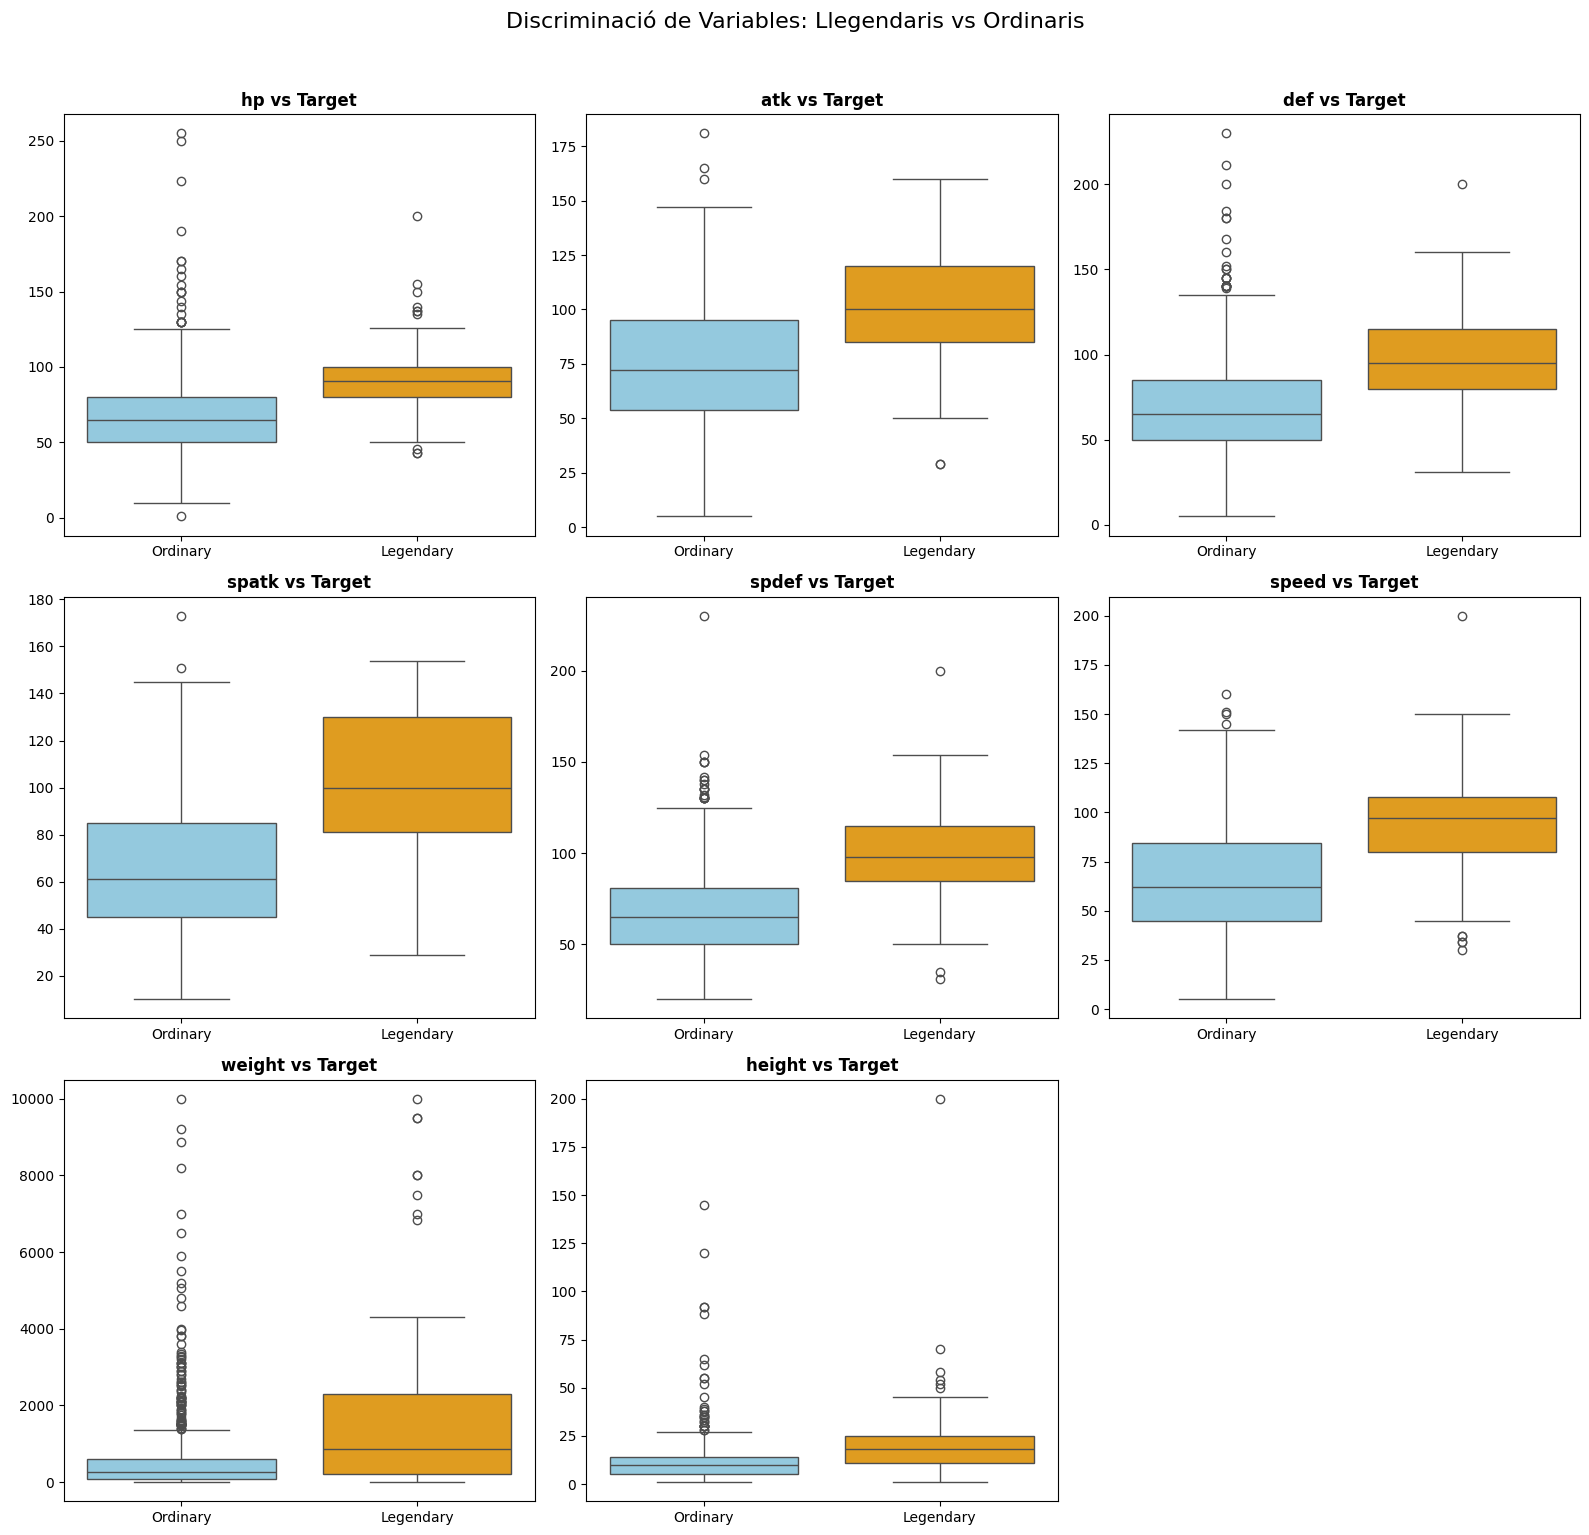

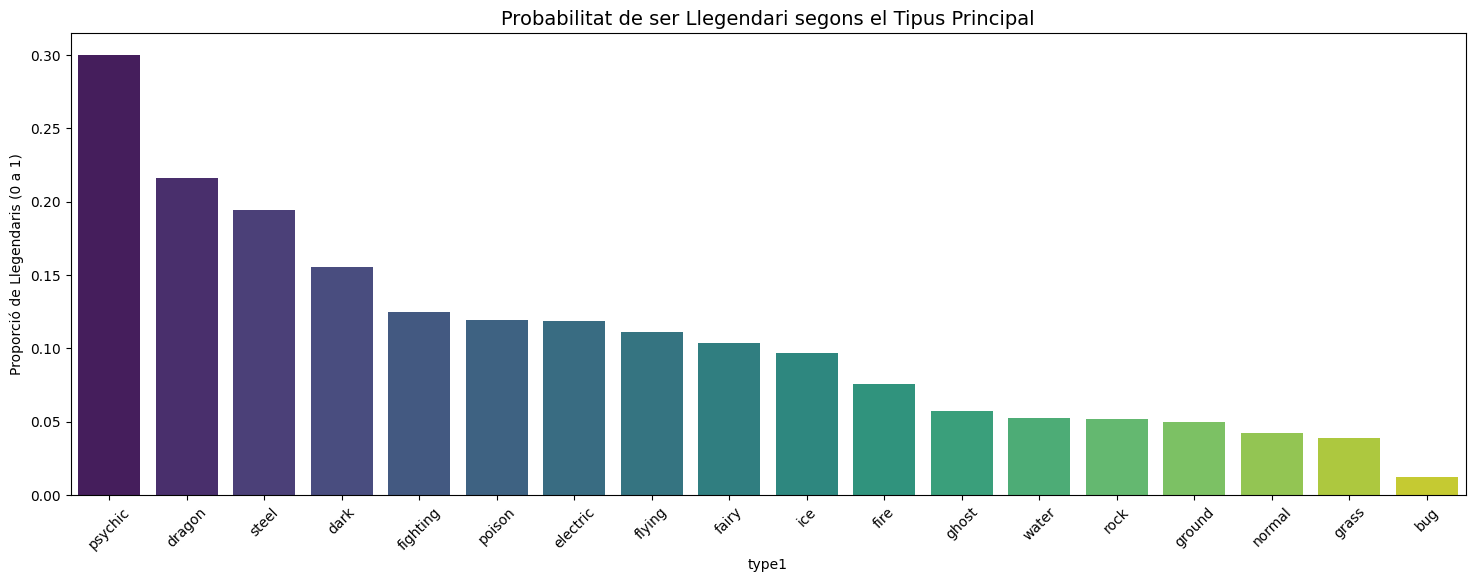

In [41]:
df_viz = df.copy()
df_viz['target'] = y
df_viz['target_label'] = df_viz['target'].map({1: 'Legendary', 0: 'Ordinary'})

numeric_feats = ['hp', 'atk', 'def', 'spatk', 'spdef', 'speed', 'weight', 'height']

cols = 3
rows = math.ceil(len(numeric_feats) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(numeric_feats):
    sns.boxplot(
            data=df_viz,
            x='target_label',
            y=col,
            hue='target_label',
            legend=False,
            ax=axes[i],
            palette={'Legendary': 'orange', 'Ordinary': 'skyblue'}
        )
    axes[i].set_title(f'{col} vs Target', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Discriminació de Variables: Llegendaris vs Ordinaris', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 6))

type_props = df_viz.groupby('type1')['target'].mean().sort_values(ascending=False)

sns.barplot(x=type_props.index, y=type_props.values, hue=type_props.index, legend=False, palette='viridis')
plt.title('Probabilitat de ser Llegendari segons el Tipus Principal', fontsize=14)
plt.ylabel('Proporció de Llegendaris (0 a 1)')
plt.xticks(rotation=45)
plt.show()

#### Poder Discriminatori (Evidència Visual)

Els Boxplots generats ens permeten jerarquitzar les variables segons la seva capacitat per separar les classes (Llegendari vs. Ordinari):

1. **Discriminadors Crítics (`spatk`, `spdef`, `hp`):**
    * Aquestes són les variables més importants. Visualment, observem que el rang interquartílic (la caixa) dels *Legendary* se situa gairebé completament per sobre de la mediana dels *Ordinary*. Això indica una separació neta: un alt nivell en estadístiques especials o vida és el segell distintiu d'un llegendari.
2. **Discriminadors Contextuals (`type1`):**
    * El gràfic de barres revela que pertànyer a tipus com **Psychic**, **Dragon** o **Steel** augmenta la probabilitat de ser llegendari fins a un 30%, mentre que tipus com *Bug* o *Normal* actuen com a predictors negatius forts.
3. **Discriminadors amb Soroll (`weight`, `speed`):**
    * Tot i que la tendència central és superior en els llegendaris, existeix un solapament considerable. En el cas del pes (`weight`), els *outliers* dels Pokémon ordinaris "envaeixen" el rang dels llegendaris, la qual cosa pot dificultar la classificació si no es tracta bé la variable.

#### Anàlisi de Redundància (Evidència del Heatmap)
Un risc habitual és la multicolinealitat (variables repetides). Les dades numèriques del mapa de calor descarten aquest problema:
* **Correlació Màxima (0.63):** Es dóna entre `height` i `weight`. És una relació lògica (mida vs massa) però moderada, lluny del llindar de risc (>0.90).
* **Independència d'Atributs:** Relacions com `spdef` vs `def` es queden en un **0.50**. Això és clau: ens indica que un Pokémon pot tenir molta Defensa Especial però poca Defensa Física. Aquestes variables aporten matisos únics i no són redundants.

### Selecció de Variables segons l'Algorisme

**Decisió Tècnica: Conservem TOTES les variables (`X_final`) per a tots els models.**
Tot i que algunes variables tenen menys poder discriminatori visual (com `def` o `atk`), la seva inclusió es justifica de manera diferent segons l'algorisme:

1. **Arbres de Decisió i Random Forest (Selecció Implícita):**
    * Aquests models són robustos al soroll. Prioritzaran automàticament les variables fortes (`spatk`, `type1`) per fer els talls principals de l'arbre.
    * El fet de mantenir variables com `weight` (amb outliers) no els perjudica, ja que poden aïllar els casos extrems en branques específiques.
2. **KNN i SVM (Sensibles a la Dimensionalitat):**
    * En models basats en distància, incloure variables que no separen bé les classes podria introduir "soroll".
    * No obstant això, com que hem demostrat amb el Heatmap que **no hi ha redundància** (cada variable aporta informació nova) i hem aplicat **`StandardScaler`** (per eliminar biaixos de magnitud), mantenir variables com `def` ajuda a definir millor la posició del Pokémon en l'espai multidimensional. Eliminar-les suposaria una pèrdua d'informació subtil que, combinada, pot ser decisiva per als casos límit (borderline).

### Conclusions de l'Anàlisi i Processament
Un cop finalitzada l'auditoria, la neteja i l'anàlisi exploratòria (EDA), podem extreure les següents conclusions definitives sobre la viabilitat del projecte:

#### Coneixement Extret: El "Perfil Llegendari"
Hem aconseguit caracteritzar matemàticament què defineix un Pokémon Llegendari. L'anàlisi indica que la condició de "llegendari" no és aleatòria, sinó que respon a un patró clar:

* **Superioritat Especial:** Les variables **`spatk`** (Atac Especial), **`spdef`** (Defensa Especial) i **`hp`** són els indicadors més fiables. Els llegendaris destaquen per "poders màgics" més que per força física bruta.
* **Elitisme de Tipus:** Existeix una forta correlació entre el Tipus i el Rang. Pertànyer als tipus **Psychic**, **Dragon** o **Steel** incrementa dràsticament la probabilitat de ser llegendari, mentre que tipus com *Bug* o *Normal* són pràcticament exclusius dels Pokémon ordinaris.
* **Independència de Variables:** Les correlacions entre atributs són moderades (màx. 0.63), la qual cosa confirma que cada estadística aporta informació única i vàlida per al model.

#### Identificació de Classes
**És possible identificar les classes? Sí, rotundament.**
L'anàlisi visual (Boxplots) ha mostrat que existeix una separació clara en les distribució de les variables clau. La distància entre la mediana dels llegendaris i la dels ordinaris en variables com l'Atac Especial és prou gran perquè algoritmes com *Random Forest* o *KNN* puguin traçar fronteres de decisió efectives.

#### Problemes i Reptes per a la Classificació
Malgrat la viabilitat, hem detectat dos obstacles crítics que haurem de gestionar durant l'entrenament:

* **Desequilibri Sever de Classes (El repte principal):**
    * Tenim una relació de **932 (Ordinaris)** vs **93 (Llegendaris)**. La classe positiva representa menys del **9%** de les dades.
    * Un model "mandrós" podria predir sempre "Ordinari" i obtenir un 91% d'encert (Accuracy), però seria inútil. Caldrà utilitzar tècniques d'estratificació i mètriques com el *F1-Score*.
* **Ambigüitat en la Zona Mitjana (Pseudo-Llegendaris):**
    * Hem detectat *outliers* en la classe ordinària (Pokémon "Pseudo-llegendaris" com *Dragonite* o *Metagross*) que tenen estadístiques superiors a molts llegendaris menors.
    * Aquests casos generaran **Falsos Positius**. El model haurà de filar molt prim (aprofitant variables com el Tipus o la Velocitat) per distingir un Pokémon molt fort d'un de veritablement llegendari.

----

## Classificació Binària: Llegendari vs Ordinari
## Selecció i Justificació d'Algorismes

Per abordar el problema de classificació binària (Llegendari vs. No Llegendari), hem seleccionat quatre algorismes que representen diferents paradigmes d'aprenentatge automàtic. Aquesta varietat ens permetrà comparar com es comporten les dades sota diferents hipòtesis matemàtiques.

A continuació, justifiquem la idoneïtat de cadascun per al dataset de Pokémon:

### 1. Regressió Logística (Baseline Lineal)
És el punt de partida estàndard per a qualsevol problema de classificació binària.

* **Per què és adequat:** Ens permetrà establir una línia base (*baseline*) de rendiment. La nostra hipòtesi és que hi ha una relació monòtona entre les estadístiques i ser llegendari (a més atac, més probabilitat). La Regressió Logística modela perfectament aquesta relació lineal directa.
* **Avantatge Addicional:** A diferència d'altres models "caixa negra", aquest ens proporciona la **probabilitat** exacta (de 0 a 1) de ser llegendari, la qual cosa és molt útil per analitzar els casos límit (els "pseudo-llegendaris").

### 2. Màquines de Vector de Suport (SVM)
Aquest algorisme busca l'hiperplà òptim que separa les classes amb el màxim marge possible.
* **Per què és adequat:** Les SVM són particularment potents en datasets amb **alta dimensionalitat** (recordem que hem passat d'11 a 34 variables amb el *One-Hot Encoding*) i **poques mostres** (~1000 files), com és el nostre cas.
* **Capacitat:** Mitjançant l'ús de *kernels* (com l'RBF), l'SVM pot trobar fronteres de decisió complexes i no lineals, ajudant a distingir aquells Pokémon ordinaris molt forts dels llegendaris febles que es solapen en l'espai.

### 3. Arbres de Decisió (Decision Trees)
Aquests models divideixen l'espai de dades mitjançant regles lògiques seqüencials (Ex: *"Si Atac Especial > 120 i Tipus és Drac -> Llegendari"*).

* **Per què és adequat:** A l'EDA hem vist que certes variables (`spatk`, `hp`) tenen llindars molt clars que separen les classes. Els arbres excel·leixen identificant aquests "talls" naturals.
* **Robustesa:** Són menys sensibles als *outliers* (com els Pokémon ordinaris amb pesos gegants) que els models basats en distàncies, ja que poden aïllar aquests casos extrems en branques específiques sense distorsionar tot el model.

### 4. K-Veïns Més Propers (KNN)
És un algorisme basat en instàncies que classifica un punt segons la classe majoritària dels seus veïns més propers en l'espai vectorial.

* **Per què és adequat:** La nostra hipòtesi fonamental és que "els Pokémon similars tenen rangs similars". KNN captura directament aquesta estructura local.
* **Requisit Complert:** KNN és molt sensible a les escales de les variables (el pes dominaria sobre l'atac). Com que hem aplicat l'**`StandardScaler`** en la fase de processament, hem habilitat aquest algorisme perquè funcioni correctament, calculant distàncies euclidianes reals entre les estadístiques de combat.

### Resum de l'Estratègia
Utilitzarem aquests quatre models per cobrir diferents enfocaments:

* **Linealitat:** Regressió Logística.
* **Marge i Dimensionalitat:** SVM.
* **Regles i Llindars:** Arbres de Decisió.
* **Proximitat i Similitud:** KNN.

Donat el fort desequilibri de classes detectat (9% Llegendaris), en la implementació de tots aquests algorismes haurem de tenir en compte paràmetres de balanceig (com `class_weight='balanced'`) per evitar que el model ignori la classe minoritària.

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score

# --- 1. SPLIT ÚNIC I ESTRATIFICAT ---
# stratify=y és OBLIGATORI pel teu desbalanceig
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y,
    test_size=0.2,    # 20% per test és estàndard
    stratify=y,       # Manté la proporció 91/9 en train i test
    random_state=42   # Perquè els resultats siguin reproduïbles
)

print(f"Grandària Train: {X_train.shape[0]} files")
print(f"Grandària Test: {X_test.shape[0]} files")


# --- 2. DEFINICIÓ DELS 4 MODELS ---
# Posem els models en un diccionari per poder iterar fàcilment
# Apliquem class_weight='balanced' a qui ho suporta
models = {
    "Regressió Logística": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    "SVM (Support Vector)": SVC(class_weight='balanced', kernel='rbf', probability=True, random_state=42),
    "Arbre de Decisió": DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=5),
    "KNN (K-Nearest Neighbors)": KNeighborsClassifier(n_neighbors=5) # KNN no té class_weight, és l'excepció
}

# --- 3. ENTRENAMENT I AVALUACIÓ MASSIVA ---
print("\n--- RESULTATS PRELIMINARS ---")

for nom, model in models.items():
    # A. Entrenar
    model.fit(X_train, y_train)

    # B. Predir
    y_pred = model.predict(X_test)

    # C. Avaluar (Mirem F1-Score perquè l'Accuracy enganya en dades desbalancejades)
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    print(f"\nModel: {nom}")
    print(f"  -> Accuracy: {acc:.4f}")
    print(f"  -> F1-Score (Clau per desbalanceig): {f1:.4f}")

Grandària Train: 820 files
Grandària Test: 205 files

--- RESULTATS PRELIMINARS ---

Model: Regressió Logística
  -> Accuracy: 0.8976
  -> F1-Score (Clau per desbalanceig): 0.6038

Model: SVM (Support Vector)
  -> Accuracy: 0.9415
  -> F1-Score (Clau per desbalanceig): 0.7143

Model: Arbre de Decisió
  -> Accuracy: 0.9171
  -> F1-Score (Clau per desbalanceig): 0.5641

Model: KNN (K-Nearest Neighbors)
  -> Accuracy: 0.9268
  -> F1-Score (Clau per desbalanceig): 0.3478



Els números parlen clar i ens ensenyen una lliçó important sobre per què no ens hem de fiar de l'*Accuracy*:

1. **El "Guanyador": SVM (Support Vector Machine)**
* **F1-Score: 0.7143** (El més alt amb diferència).
* **Per què?** L'SVM amb `class_weight='balanced'` i kernel `rbf` ha estat capaç de trobar una frontera complexa que separa bé els llegendaris, penalitzant molt els errors en la classe minoritària. És el model que millor entén què fa especial a un llegendari.


2. **La "Trampa": KNN (K-Nearest Neighbors)**
* **Accuracy: 92,6%** (Sembla boníssim, oi?)
* **F1-Score: 0.3478** (Desastrós).
* **Què ha passat?** Com que el KNN no té un paràmetre intern de `class_weight` (pesos de classe), s'ha deixat portar per la majoria. Ha predit gairebé tot com a "Ordinari". En encertar tots els ordinaris (que són el ~91%), té una *Accuracy* alta, però en fallar la majoria de llegendaris, el seu *F1* s'enfonsa. **És un model esbiaixat.**


3. **Els Intermedis: Regressió Logística i Arbre**
* La **Regressió Logística** (F1 0.60) ha funcionat sorprenentment bé per ser un model simple lineal.
* L'**Arbre de Decisió** (F1 0.56) sembla haver patit una mica més, probablement limitat per la profunditat o confós pels outliers.

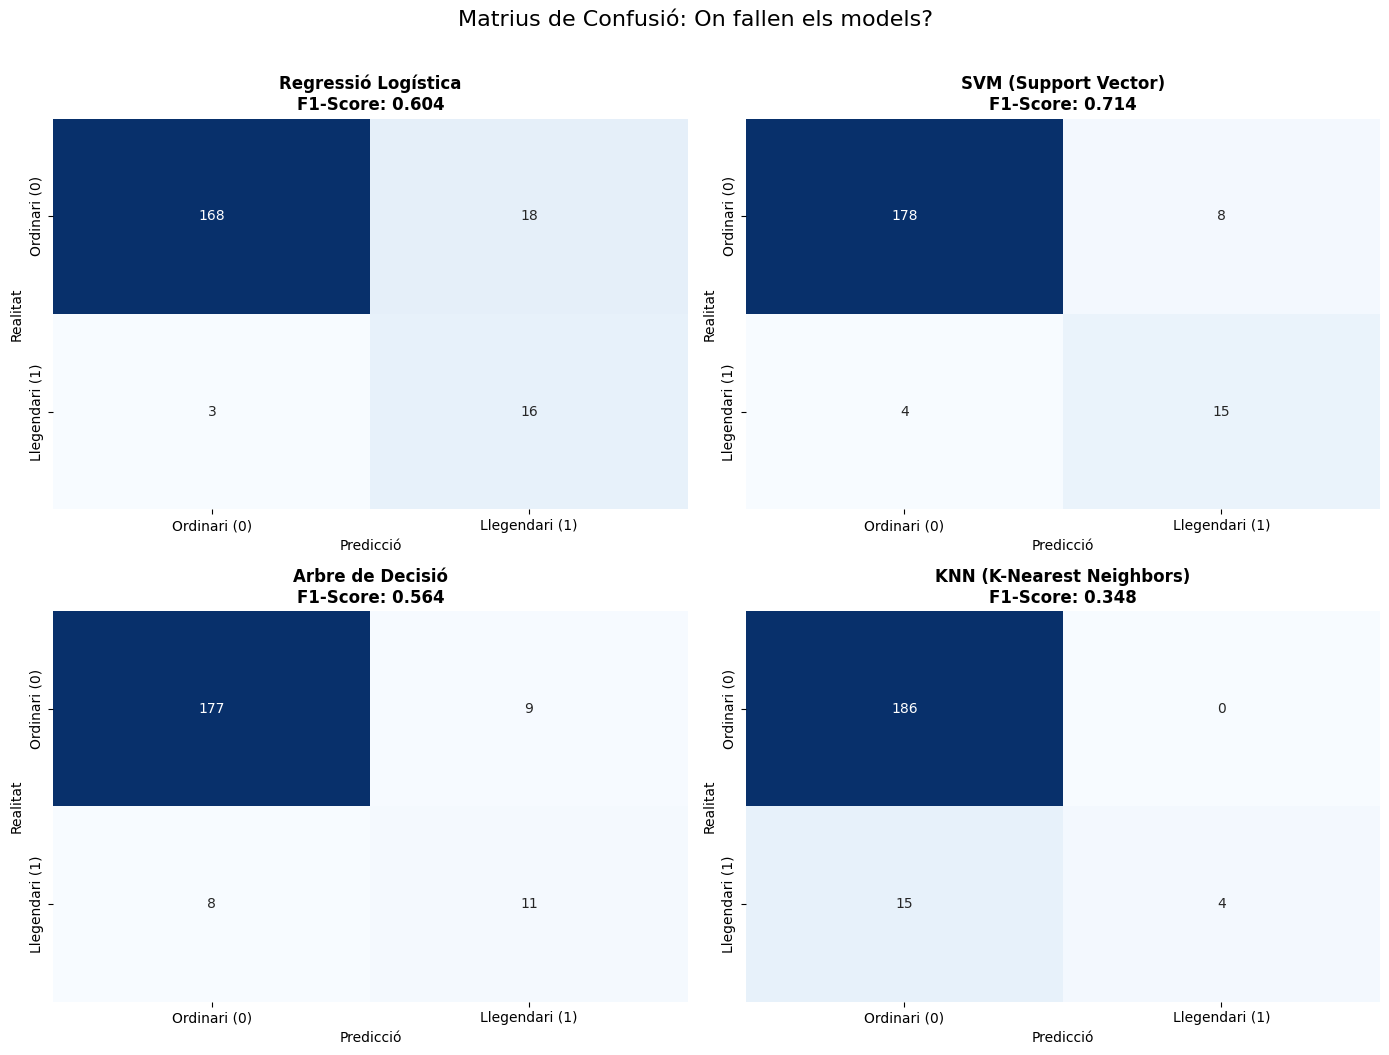

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Configuració de la figura
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Iterem sobre els models que ja tens entrenats al diccionari 'models'
for i, (nom, model) in enumerate(models.items()):
    # Predicció
    y_pred = model.predict(X_test)

    # Calculem la matriu
    cm = confusion_matrix(y_test, y_pred)

    # Dibuixem el Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                xticklabels=['Ordinari (0)', 'Llegendari (1)'],
                yticklabels=['Ordinari (0)', 'Llegendari (1)'])

    axes[i].set_title(f"{nom}\nF1-Score: {f1_score(y_test, y_pred):.3f}", fontweight='bold')
    axes[i].set_xlabel('Predicció')
    axes[i].set_ylabel('Realitat')

plt.tight_layout()
plt.suptitle('Matrius de Confusió: On fallen els models?', fontsize=16, y=1.05)
plt.show()

In [44]:
from sklearn.metrics import classification_report

print("--- DETALL DE MÈTRIQUES PER CLASSE (LLEGENDARI = 1) ---")

for nom, model in models.items():
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)

    # Extraiem només les dades de la classe 1 (Llegendari)
    recall = report['1']['recall']
    precision = report['1']['precision']
    f1 = report['1']['f1-score']

    print(f"\nModel: {nom}")
    print(f"  -> Recall (Llegendaris trobats): {recall:.2%}")
    print(f"  -> Precision (Fiabilitat de la predicció): {precision:.2%}")
    print(f"  -> F1-Score (Equilibri): {f1:.3f}")

--- DETALL DE MÈTRIQUES PER CLASSE (LLEGENDARI = 1) ---

Model: Regressió Logística
  -> Recall (Llegendaris trobats): 84.21%
  -> Precision (Fiabilitat de la predicció): 47.06%
  -> F1-Score (Equilibri): 0.604

Model: SVM (Support Vector)
  -> Recall (Llegendaris trobats): 78.95%
  -> Precision (Fiabilitat de la predicció): 65.22%
  -> F1-Score (Equilibri): 0.714

Model: Arbre de Decisió
  -> Recall (Llegendaris trobats): 57.89%
  -> Precision (Fiabilitat de la predicció): 55.00%
  -> F1-Score (Equilibri): 0.564

Model: KNN (K-Nearest Neighbors)
  -> Recall (Llegendaris trobats): 21.05%
  -> Precision (Fiabilitat de la predicció): 100.00%
  -> F1-Score (Equilibri): 0.348



### 2.3. Anàlisi de Resultats: Quantitat vs. Qualitat

Observant les Matrius de Confusió, detectem un comportament molt diferenciat entre els millors models:

#### 1. Regressió Logística: El Caçador Agressiu (Màxim Recall)

* **El que has vist:** Aquest model detecta la gran majoria de Pokémon Llegendaris (pocs Falsos Negatius).
* **El problema (El Preu):** En ser tan agressiu per trobar llegendaris, també comet molts errors a l'inrevés: classifica molts Pokémon normals com a llegendaris (**Falsos Positius**).
* **Conclusió:** Té molta *Sensibilitat* (no se li escapa gairebé ningú) però poca *Precisió* (esbiaixa massa).

#### 2. SVM: L'Equilibrista (Màxim F1-Score)

* **Comportament:** Potser deixa escapar algun llegendari més que la Regressió Logística (té algun Fals Negatiu més), però a canvi, s'equivoca molt menys amb els Pokémon normals.
* **Per què guanya en F1:** L'F1-Score és la mitjana entre no deixar-se llegendaris i no inventar-se'ls. L'SVM troba el millor balanç entre els dos mons.

#### 3. KNN: El Conservador (Màxima Precisió, Mínim Recall)

* **Comportament:** Com veus a la matriu, gairebé no prediu llegendaris.
* **Conclusió:** Quan diu "és llegendari", sol tenir raó (Precisió alta), però se li escapen la majoria (Recall pèssim). Per això el seu F1 és tan baix (0.34).

Aquests números són **or pur** per al teu treball. Confirmen matemàticament tot el que hem intuït mirant els gràfics.

Aquí tens l'anàlisi detallada d'aquests resultats per incloure al teu informe. He titulat la secció per destacar la comparació entre quantitat (Recall) i qualitat (Precision).

---

### 2.3. Anàlisi Quantitatiu: El Dilema Precisió-Exhaustivitat

L'extracció de les mètriques detallades per a la classe positiva (Llegendari) revela el comportament intern de cada algorisme i confirma el repte del desequilibri de classes:

#### 1. Regressió Logística: "El Detector Agressiu"

* **Recall (84,21%):** És el model més sensible. De tots els llegendaris reals que hi havia al Test, n'ha trobat gairebé el 85%. Si el nostre objectiu fos no perdre cap possible llegendari, aquest seria el millor model.
* **Precisió (47,06%):** El preu a pagar és alt. Més de la meitat de les vegades que diu "És Llegendari", s'equivoca (són falsos positius). Això passa perquè, en intentar caçar-los tots, dispara a tot el que tingui stats mínimament altes.

#### 2. SVM: "L'Equilibrista (Model Guanyador)"

* **F1-Score (0,714):** És la mètrica reina en datasets desbalancejats, i l'SVM guanya per golejada.
* **El Balanç:** Manté un Recall molt alt (**78,95%**, només una mica per sota de la Regressió) però millora dràsticament la Precisió (**65,22%**).
* **Conclusió:** És el model més intel·ligent. Entén millor la frontera complexa entre un Pokémon "molt fort" (pseudo-llegendari) i un de "veritablement llegendari", gràcies al seu kernel RBF.

#### 3. KNN: "El Conservador Extrem"

* **Precisió (100%):** Aquesta dada és enganyosa. Quan s'atreveix a dir que un Pokémon és llegendari, té raó el 100% de les vegades. No comet falsos positius.
* **Recall (21,05%):** Aquí és on falla estrepitosament. Se li escapen el **80% dels llegendaris**. Com que es basa en la majoria de veïns i no té pesos corregits (`class_weight`), necessita que un punt estigui envoltat de llegendaris per classificar-lo com a tal. En un dataset on el 91% són ordinaris, això passa poquíssimes vegades. **És un model inútil per a la detecció.**

#### 4. Arbre de Decisió: "Limitat"

* Es queda en terra de ningú. Amb un Recall del 57% i una Precisió del 55%, és superat tant en capacitat de detecció (per la Regressió) com en fiabilitat global (per l'SVM). Probablement necessita més profunditat o és massa inestable davant la variabilitat de les dades.

---

### Conclusió Final de la Classificació

Triem l'**SVM (Support Vector Machine)** com el model òptim per a aquest problema. Tot i que la Regressió Logística detecta més casos, l'SVM ofereix una predicció molt més robusta i fiable, minimitzant el soroll dels falsos positius sense sacrificar excessivament la capacitat de detecció.